In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [27]:
df.info()
df['ChestPainType'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [11]:
print(df.shape)
df.describe()

(918, 12)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [14]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

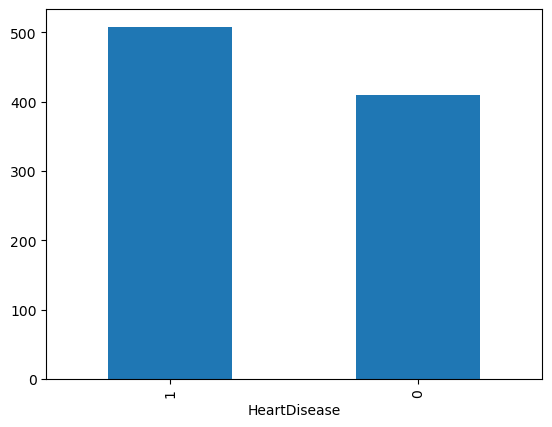

In [15]:
df['HeartDisease'].value_counts().plot(kind="bar")

In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

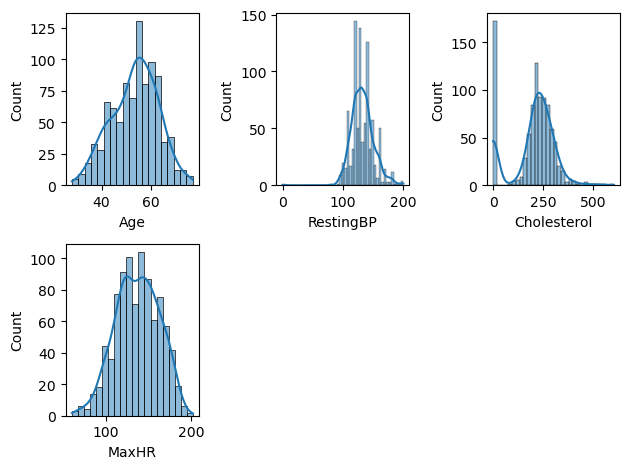

In [8]:

def ploting(var, num):
    plt.subplot(2, 3, num)
    # Use sns.histplot instead of plt.histplot
    sns.histplot(df[var], kde=True)
    
ploting('Age', 1)
ploting('RestingBP', 2)
ploting('Cholesterol', 3)
ploting('MaxHR', 4)
plt.tight_layout()


In [9]:
# some person have cholestrol of zero and that is impossible approx 172 peaople are having zero cholestrol (df['cholestrol'].value_counts())
# so correct out that that we should replace that value to mean value
ch_mean = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)
df['Cholesterol'] 

0      289.0
1      180.0
2      283.0
3      214.0
4      195.0
       ...  
913    264.0
914    193.0
915    131.0
916    236.0
917    175.0
Name: Cholesterol, Length: 918, dtype: float64

In [10]:
resting_bp_mean = df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)
df['RestingBP']

0      140.0
1      160.0
2      130.0
3      138.0
4      150.0
       ...  
913    110.0
914    144.0
915    130.0
916    130.0
917    138.0
Name: RestingBP, Length: 918, dtype: float64

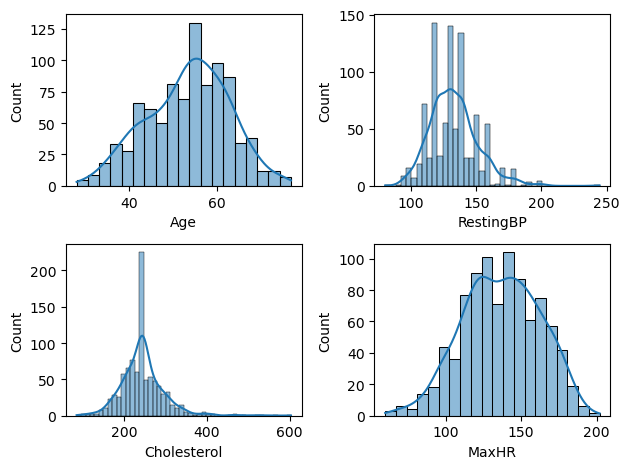

In [11]:
def ploting(var, num):
    plt.subplot(2, 2, num)
    # Use sns.histplot instead of plt.histplot
    sns.histplot(df[var], kde=True)
    
ploting('Age', 1)
ploting('RestingBP', 2)
ploting('Cholesterol', 3)
ploting('MaxHR', 4)
plt.tight_layout() 

<Axes: xlabel='Sex', ylabel='count'>

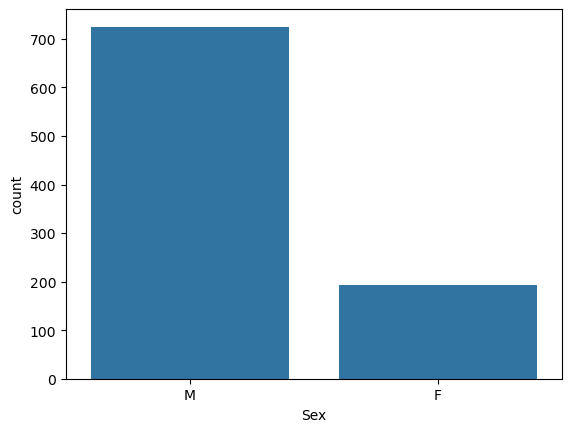

In [12]:
sns.countplot(x=df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

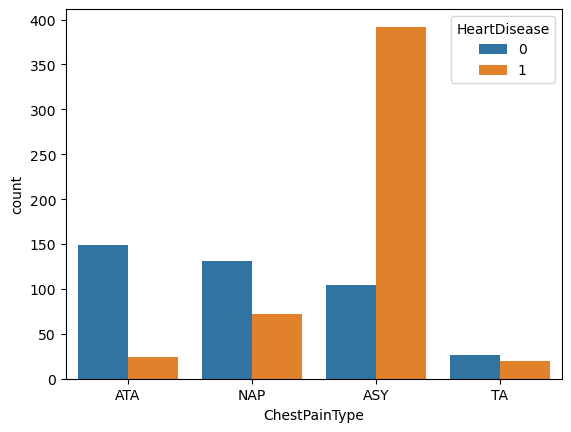

In [13]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

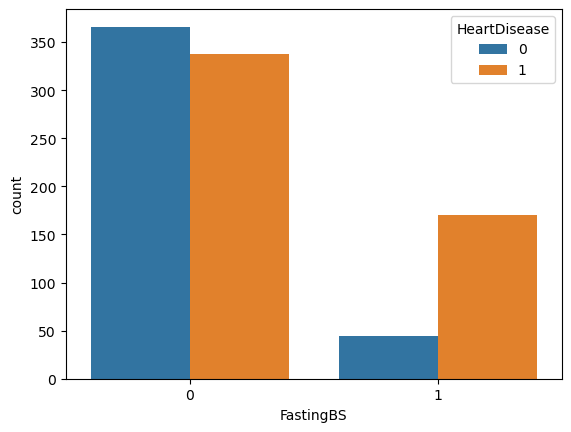

In [14]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

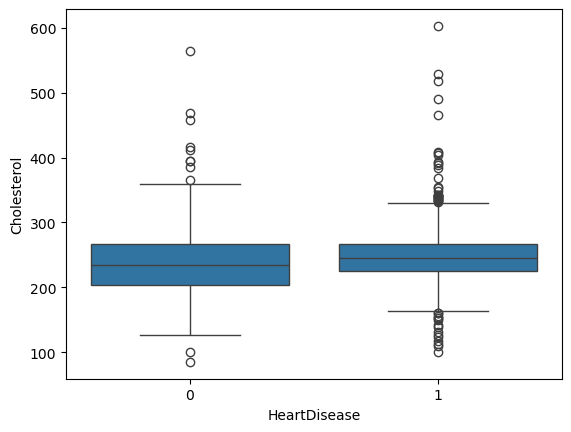

In [15]:
sns.boxplot( x=df['HeartDisease'], y=df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

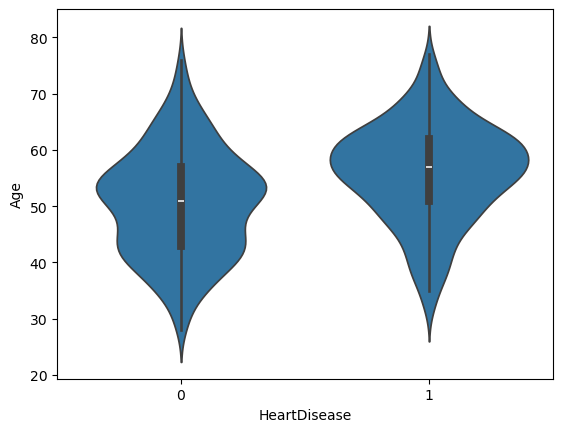

In [16]:
sns.violinplot(x=df['HeartDisease'],y=df['Age'])

<Axes: >

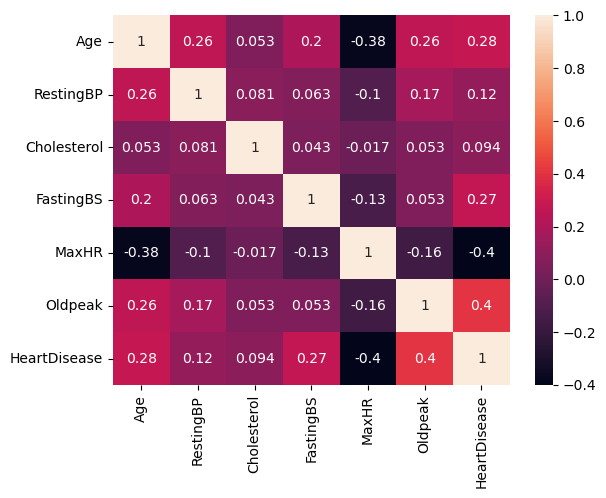

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [18]:
# data preprocessing
df_encode = pd.get_dummies(df,drop_first=True)
df_encode  # this values comes in true and false need to convert in integer

df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier




In [20]:
# START
X = df_encode.drop('HeartDisease',axis=1)
y = df_encode['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# scaling the data
scaler = StandardScaler()
X_tain_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [21]:
# model training
models={
    "logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(),
    "SVM": SVC()
}
result = []
for name,model in models.items():
    model.fit(X_tain_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'model':name,
        'Accuracy':round(acc,4), 
        "f1 score":round(f1,4)
    })

In [22]:
result

[{'model': 'logistic Regression', 'Accuracy': 0.8647, 'f1 score': 0.8805},
 {'model': 'KNN', 'Accuracy': 0.8482, 'f1 score': 0.8655},
 {'model': 'NaiveBayes', 'Accuracy': 0.8647, 'f1 score': 0.8812},
 {'model': 'DecisionTree', 'Accuracy': 0.7855, 'f1 score': 0.8138},
 {'model': 'SVM', 'Accuracy': 0.8614, 'f1 score': 0.8793}]

In [23]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.Pkl')
joblib.dump(scaler,'Scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']